In [1]:
import os
import kagglehub
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score,confusion_matrix,classification_report)

In [2]:
path = kagglehub.dataset_download("ealaxi/paysim1")

print("Dataset downloaded to:")
print(path)

Using Colab cache for faster access to the 'paysim1' dataset.
Dataset downloaded to:
/kaggle/input/paysim1


In [3]:
csv_file = os.path.join(path, "PS_20174392719_1491204439457_log.csv")
df = pd.read_csv(csv_file)
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [4]:
print("Shape :", df.shape)
df.info()

Shape : (6362620, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [5]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


In [6]:
df.isnull().sum()

,0
step,0
type,0
amount,0
nameOrig,0
oldbalanceOrg,0
newbalanceOrig,0
nameDest,0
oldbalanceDest,0
newbalanceDest,0
isFraud,0


In [7]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


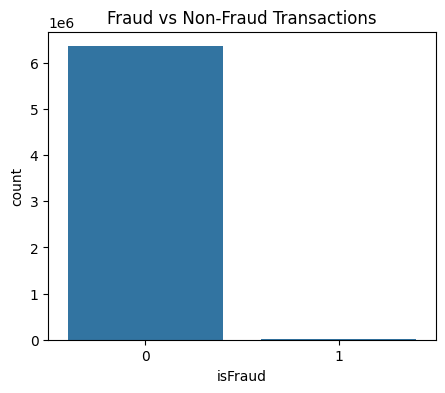

In [8]:
plt.figure(figsize=(5,4))
sns.countplot(x='isFraud', data=df)
plt.title("Fraud vs Non-Fraud Transactions")
plt.show()

In [9]:
df['isFraud'].value_counts()

,count
isFraud,
0,6354407
1,8213


In [10]:
df['isFraud'].value_counts(normalize=True) * 100

,proportion
isFraud,
0,99.870918
1,0.129082


In [11]:
df['type'].value_counts()

,count
type,
CASH_OUT,2237500
PAYMENT,2151495
CASH_IN,1399284
TRANSFER,532909
DEBIT,41432


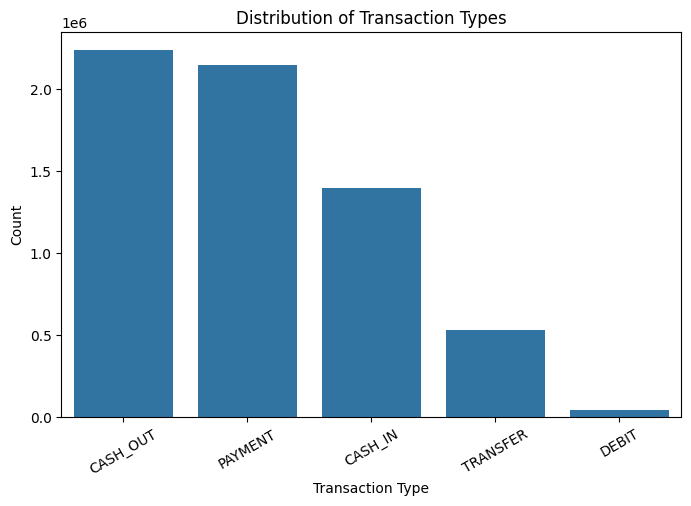

In [14]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='type', order=df['type'].value_counts().index)
plt.title("Distribution of Transaction Types")
plt.xlabel("Transaction Type")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.show()

In [16]:
le = LabelEncoder()
df['type'] = le.fit_transform(df['type'])
df.head()

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,3,9839.64,170136.0,160296.36,0.0,0.0,0,0
1,1,3,1864.28,21249.0,19384.72,0.0,0.0,0,0
2,1,4,181.00,181.0,0.00,0.0,0.0,1,0
3,1,1,181.00,181.0,0.00,21182.0,0.0,1,0
4,1,3,11668.14,41554.0,29885.86,0.0,0.0,0,0


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 9 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            int64  
 2   amount          float64
 3   oldbalanceOrg   float64
 4   newbalanceOrig  float64
 5   oldbalanceDest  float64
 6   newbalanceDest  float64
 7   isFraud         int64  
 8   isFlaggedFraud  int64  
dtypes: float64(5), int64(4)
memory usage: 436.9 MB


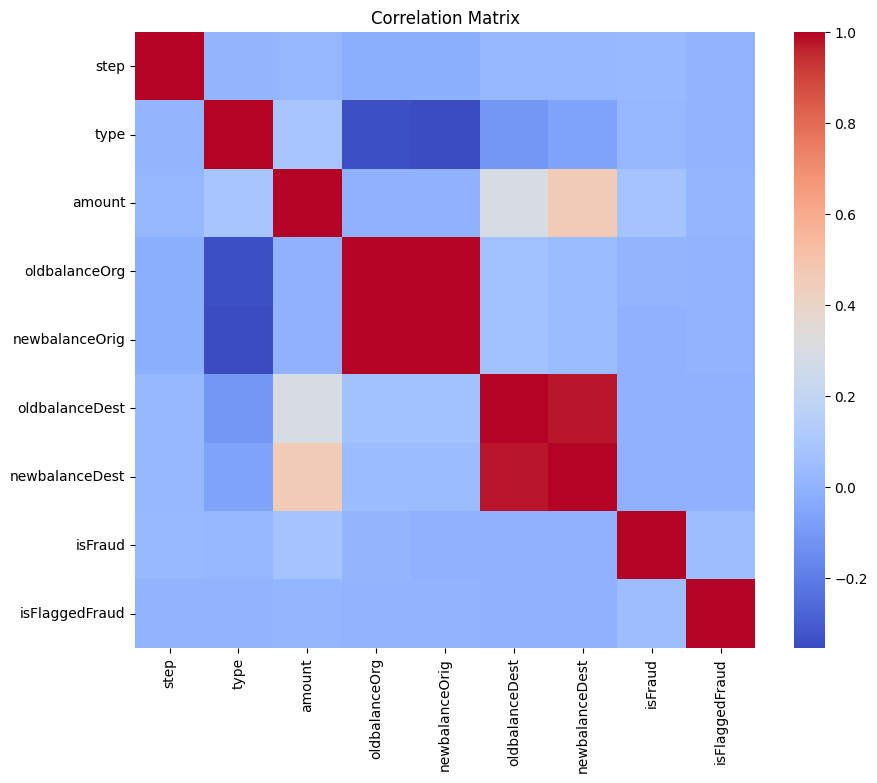

In [18]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), cmap='coolwarm', annot=False)
plt.title("Correlation Matrix")
plt.show()

In [19]:
X = df.drop('isFraud', axis=1)
y = df['isFraud']
print("Features :", X.shape)
print("Target :", y.shape)

Features : (6362620, 8)
Target : (6362620,)


In [20]:
df = df.sample(n=200000, random_state=42)

In [21]:
X = df.drop('isFraud', axis=1)
y = df['isFraud']

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
print("Training Set:", X_train.shape)
print("Testing Set :", X_test.shape)

Training Set: (160000, 8)
Testing Set : (40000, 8)


In [23]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("\nClassification Report\n")
print(classification_report(y_test, y_pred_lr))

Accuracy : 0.9993

Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     39946
           1       0.91      0.54      0.67        54

    accuracy                           1.00     40000
   macro avg       0.95      0.77      0.84     40000
weighted avg       1.00      1.00      1.00     40000



In [24]:
print("\nClassification Report\n")
print(classification_report(y_test, y_pred_lr))


Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     39946
           1       0.91      0.54      0.67        54

    accuracy                           1.00     40000
   macro avg       0.95      0.77      0.84     40000
weighted avg       1.00      1.00      1.00     40000



In [25]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
print("Accuracy :", accuracy_score(y_test, y_pred_dt))

Accuracy : 0.9993


In [26]:
print("\nClassification Report\n")
print(classification_report(y_test, y_pred_dt))


Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     39946
           1       0.74      0.74      0.74        54

    accuracy                           1.00     40000
   macro avg       0.87      0.87      0.87     40000
weighted avg       1.00      1.00      1.00     40000



In [27]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("Accuracy :", accuracy_score(y_test, y_pred_rf))

Accuracy : 0.99965


In [28]:
print("\nClassification Report\n")
print(classification_report(y_test, y_pred_rf))


Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     39946
           1       1.00      0.74      0.85        54

    accuracy                           1.00     40000
   macro avg       1.00      0.87      0.93     40000
weighted avg       1.00      1.00      1.00     40000



In [29]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf)
    ]
})

results.sort_values(by="Accuracy", ascending=False)

,Model,Accuracy
2,Random Forest,0.99965
0,Logistic Regression,0.99930
1,Decision Tree,0.99930


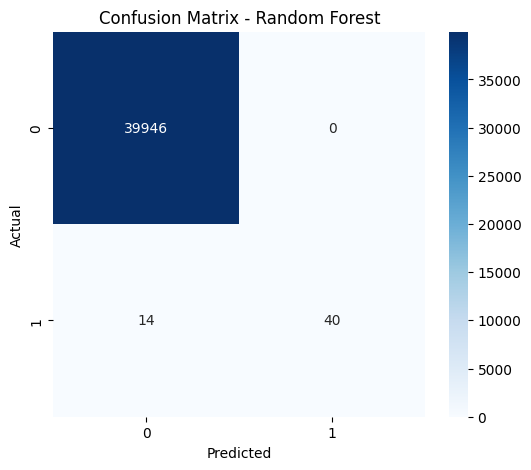

In [30]:
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

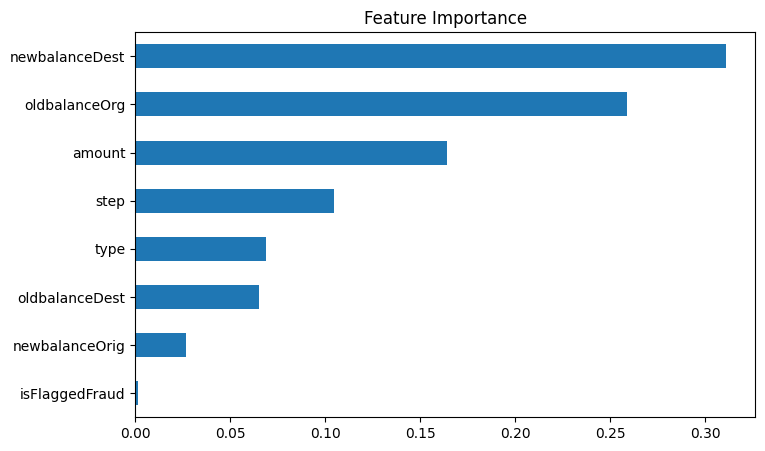

In [31]:
importance = pd.Series(rf.feature_importances_,index=X.columns)
importance.sort_values().plot(kind='barh',figsize=(8,5))
plt.title("Feature Importance")
plt.show()

In [36]:
sample = X_test.iloc[[0]]

prediction = rf.predict(sample)
probability = rf.predict_proba(sample)

print("Prediction :", "Fraud" if prediction[0] == 1 else "Genuine")
print("Probability :", probability)

Prediction : Genuine
Probability : [[1. 0.]]
